In [1]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
DataClass = STL_2D_Kernel_Torch
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE

print("Working on device:", _DEFAULT_DEVICE)


import torch

Parent directory added to sys.path: .../STL-Dev
Dataset dirctory used: .../STL-Dev/data/test
Working on device: cpu


In [ ]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

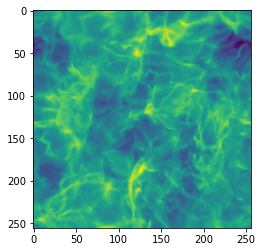

In [3]:
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]
data = DataClass(im[0,0], pbc=True)
plt.imshow(data.array.cpu().numpy())

In [ ]:
wavelet_op = data.get_wavelet_op()
mean = wavelet_op.mean(data=data)#, wavelet_convolved=False)
print("Mean of stl_data_type:", mean)

Mean of stl_data_type: tensor(20.3195, dtype=torch.float64)


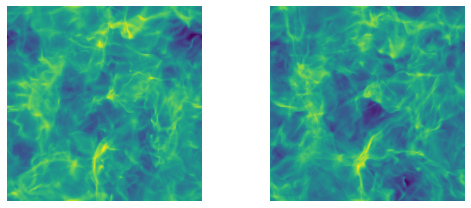

Covariance = tensor(0.0247, dtype=torch.float64)



In [5]:
# Prepare centralized data for covariance tests
stl_data0 = DataClass(im[0,0]-im[0,0].mean())
stl_data1 = DataClass(im[1,0]-im[1,0].mean())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes = axes.ravel()
axes[0].imshow(stl_data0.array.cpu().numpy())
axes[0].axis('off')
axes[1].imshow(stl_data1.array.cpu().numpy())
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Test of Cov
cov = wavelet_op.cov(stl_data0, stl_data1)#, wavelet_convolved=False)
print("Covariance = " + str(cov))
print()

In [6]:
target = im[0,0,:,:]
target = DataClass(target, pbc=False)
st_op = target.get_ST_op()

compute_cross_matrix = None
seed = 0

In [34]:
u1, histo1 = optimize_scattering_LBFGS(
        target=target,
        st_op_target=st_op,
        st_op_running=st_op,
        pbc_running=True,
        compute_cross_matrix=compute_cross_matrix,        
        nbatch=1,
        max_iter=50,
        lr=1,
        history_size=50,
        print_iter=10,
        verbose=True,
        seed=seed,
    )

Running synthesis on device : cpu dtype : torch.float64
Initial shape for u: (1, 1, 256, 256)
Replacing existing var_ref in ST_Op
Replacing existing S2_ref_sqrt_chan_diag in ST_Op
Synthesis on 3970 ST coefficients
[LBFGS] inner iter 10, loss = 4.989371e-01
[LBFGS] inner iter 20, loss = 5.791897e-02
[LBFGS] inner iter 30, loss = 2.896213e-02
[LBFGS] inner iter 40, loss = 1.999099e-02
[LBFGS] inner iter 50, loss = 1.652718e-02
[LBFGS] inner iter 60, loss = 1.498721e-02
61 iterations of synthesis done with nbatch=1 and 3970 ST coefficients
Execution time: 24.074 s


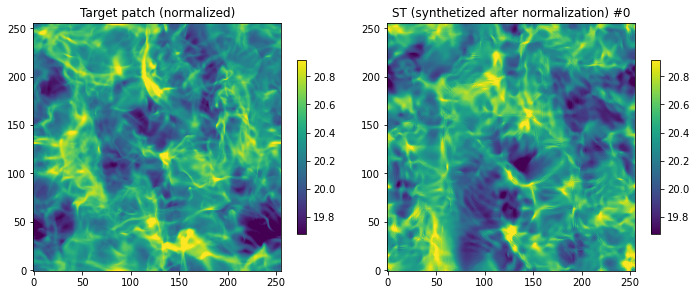

20.319510135025542
0.2543278038994038
0.2532717030966275


In [36]:
plt.figure(figsize=(10,4))
patch = im[0,0,:,:]

vmin, vmax = np.nanpercentile(patch, [1, 99])

plt.subplot(1,2,1)
#plt.imshow(np.fft.fftshift(patch), origin="lower", vmin=vmin, vmax=vmax)
plt.imshow(im[0,0,:,:], origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("Target patch (normalized)")

plt.subplot(1,2,2)
plt.imshow(u1[0].cpu().numpy(), origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(shrink=0.7)
plt.title("ST (synthetized after normalization) #0")

plt.tight_layout()
plt.show()

print(np.mean(u1.cpu().numpy()))
print(np.std(u1.cpu().numpy()))
print(np.std(patch))